# Phase 1 — Exploratory Data Analysis

Goal: give the PM concrete evidence about the dataset before any clustering work.

We answer four questions:
1. What's the language mix?
2. How long is a typical feedback comment?
3. How fragmented is the existing `Granular_Subtopic` column?
4. Is the existing label hierarchy internally consistent?

All analysis logic lives in `src/feedback/eda.py` so the same primitives can be
reused by tests and the validation panel later.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from feedback.ingest import load_feedback, summarize
from feedback import eda

df = load_feedback()
print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
df.head(3)

Loaded 11,258 rows, 7 columns


,row_id,Topic,Feedback Comment,Contextual_Subtopic,Granular_Subtopic,Severity,Sentiment
0,0,Other,.I find it a better experience,General Other,General Other - Positive Experience Feedback,Low,Positive
1,1,Feature,.More translation added,Translations & Tafseer,Translations & Tafseer - Additional Translatio...,Low,Positive
2,2,Other,.ماشاء اللہ بہت خوب کام کیا ہے \nاللہ پاک جزاۓ...,General Other,General Other - Positive Feedback,Low,Positive


## 1. Existing label distributions

Quick reference for the pre-populated columns.

In [2]:
stats = summarize(df)
for k, v in stats.items():
    print(f"{k}: {v}")

rows: 11258
topic_counts: {'Feature': 5320, 'Other': 2904, 'Bug': 1120, 'Ads': 685, 'Accuracy': 527, 'UI': 514, 'Slow': 148, 'Subscription': 40}
severity_counts: {'Low': 7762, 'Medium': 3029, 'High': 467}
sentiment_counts: {'Neutral': 5660, 'Negative': 3077, 'Positive': 2521}
unique_contextual_subtopic: 41
unique_granular_subtopic: 6021
blank_feedback: 3


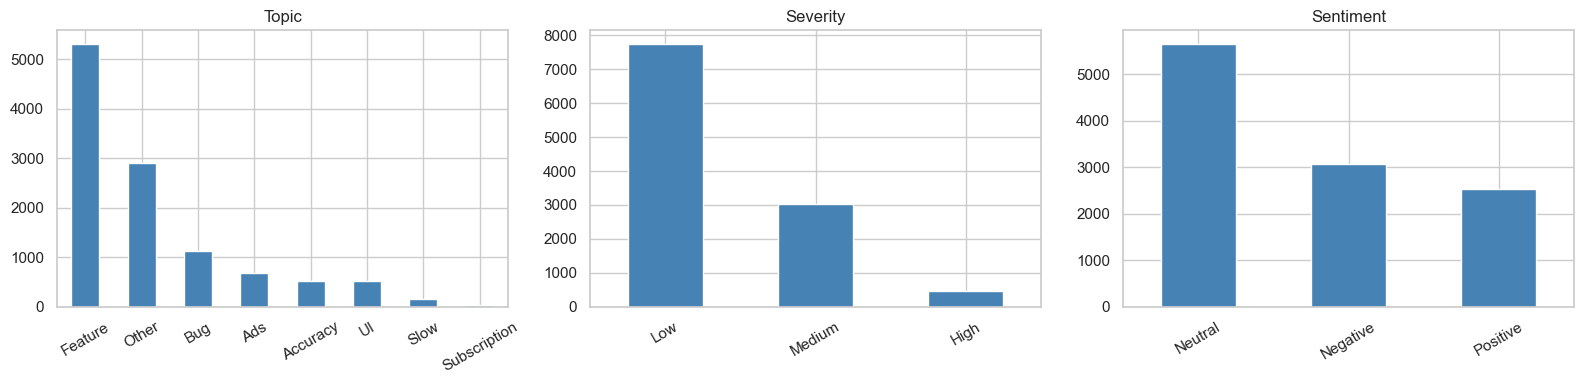

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, title in zip(
    axes,
    ["Topic", "Severity", "Sentiment"],
    ["Topic", "Severity", "Sentiment"],
):
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 2. Feedback length distribution

Drives later decisions: token budget for embeddings, whether to chunk multi-paragraph comments.

In [4]:
ls = eda.length_stats(df)
ls.describe().round(1)

,chars,words,lines
count,11258.0,11258.0,11258.0
mean,71.6,13.3,1.1
std,64.0,12.2,0.5
min,0.0,0.0,0.0
50%,50.0,9.0,1.0
90%,166.0,32.0,1.0
95%,221.1,41.0,2.0
99%,255.0,51.0,3.0
max,374.0,88.0,9.0


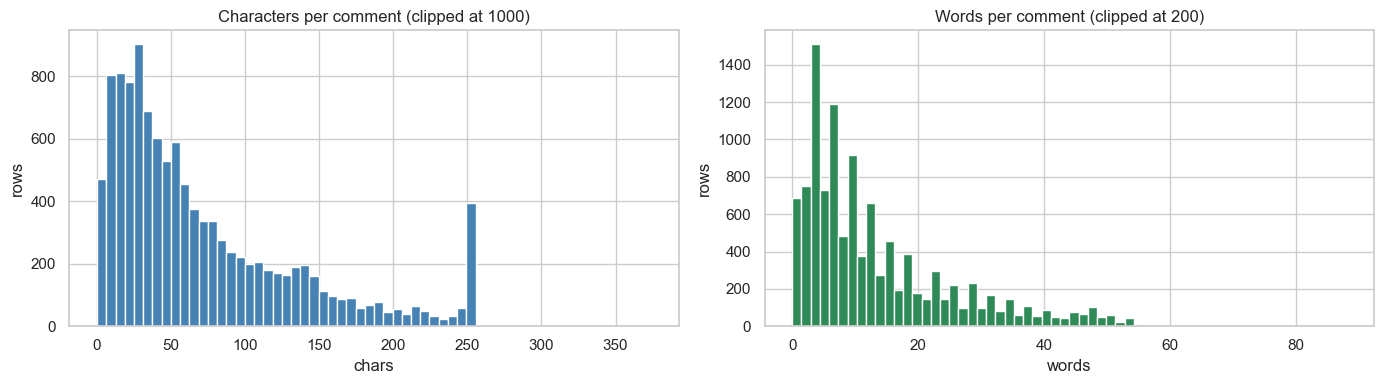

Very short (<5 chars): 282    Very long (>500 chars): 0


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(np.clip(ls.chars, 0, 1000), bins=60, color="steelblue")
axes[0].set_title("Characters per comment (clipped at 1000)")
axes[0].set_xlabel("chars"); axes[0].set_ylabel("rows")
axes[1].hist(np.clip(ls.words, 0, 200), bins=60, color="seagreen")
axes[1].set_title("Words per comment (clipped at 200)")
axes[1].set_xlabel("words"); axes[1].set_ylabel("rows")
plt.tight_layout()
plt.show()

short = (ls.chars < 5).sum()
very_long = (ls.chars > 500).sum()
print(f"Very short (<5 chars): {short}    Very long (>500 chars): {very_long}")

## 3. Language mix

Coarse 4-bucket classifier (Urdu script / Roman Urdu / English / mixed) using
Unicode script ranges and a small Roman-Urdu marker list. **Metadata only** —
no transliteration, no language-branched preprocessing. The downstream
multilingual embedding handles the real semantic work; this view exists so the
PM can see the language mix and we can spot-check translation quality later.

Feedback Comment
english        8208
roman_urdu     2248
urdu_script     637
mixed           131
other            31
blank             3
Name: count, dtype: int64

% non-English: 27.1%


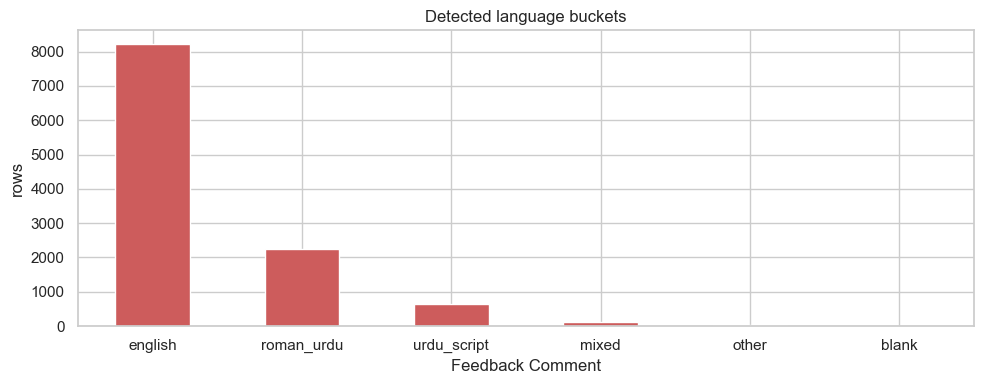

In [6]:
langs = eda.language_distribution(df)
lang_counts = langs.value_counts()
print(lang_counts)
print(f"\n% non-English: {(langs != 'english').mean() * 100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 4))
lang_counts.plot(kind="bar", ax=ax, color="indianred")
ax.set_title("Detected language buckets")
ax.set_ylabel("rows")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. `Granular_Subtopic` over-fragmentation

The headline finding for the PM. If most granular labels appear on 1–3 rows, they
are not a useful taxonomy — they are essentially row-level annotations.

In [7]:
frag = eda.fragmentation_stats(df)
for k, v in frag.items():
    print(f"{k}: {v}")

n_granular_labels: 6021
n_contextual_labels: 41
rows_per_granular_mean: 1.8697890715827936
rows_per_granular_median: 1.0
granular_singletons: 4812
granular_singletons_pct: 79.92027902341803
granular_le_3_rows: 5763
granular_le_3_rows_pct: 95.71499750871948
rows_per_contextual_mean: 274.5853658536585
rows_per_contextual_median: 43.0


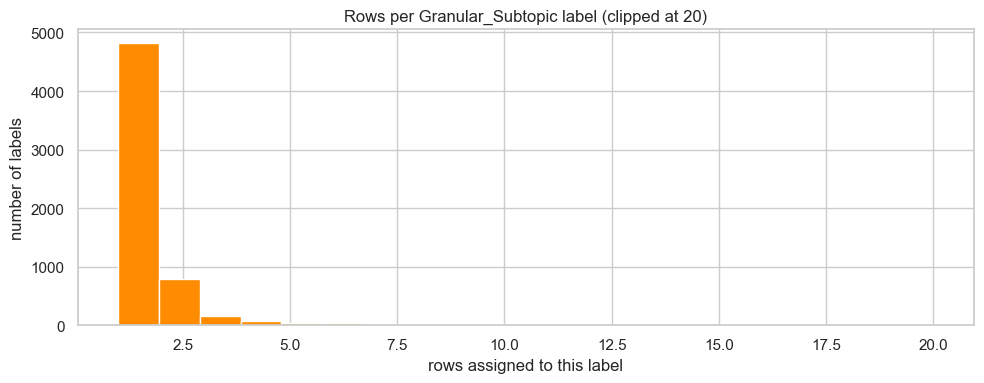

In [8]:
granular_counts = df["Granular_Subtopic"].value_counts()
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(np.clip(granular_counts, 0, 20), bins=20, color="darkorange")
ax.set_title("Rows per Granular_Subtopic label (clipped at 20)")
ax.set_xlabel("rows assigned to this label")
ax.set_ylabel("number of labels")
plt.tight_layout()
plt.show()

### Hierarchy consistency

If `Granular_Subtopic` is a true child of `Contextual_Subtopic`, every granular
label should have exactly one parent. Multiple parents per granular label means
the labels were generated without a consistent hierarchy.

In [9]:
eda.cross_label_consistency(df)

,granular_count
distinct_parents,
1,6017
2,4


## Takeaways for the PM

Findings will be filled in by the executed cells above. Expected story:

- **Language mix** is dominated by Urdu / Roman Urdu / English. This justifies a multilingual embedding (`multilingual-e5-large`) over English-only models.
- **Lengths are short-to-medium**, with a long tail. No chunking needed; raw comment fits in one embedding pass.
- **`Granular_Subtopic` is over-fragmented** — a large fraction of labels apply to ≤3 rows. This confirms the brief: re-derive the taxonomy via clustering rather than treating these as ground truth.
- **Hierarchy is inconsistent** — granular labels with multiple Contextual_Subtopic parents indicate the existing labels were generated row-by-row, not from a controlled taxonomy.

Phase 2 next: normalize text, generate embeddings, cache to Parquet.